In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

%matplotlib inline

In [10]:
result_figure_path = "../results/figures/normalized_mean/"

In [2]:
statistic = pd.read_table("../results/processedData/normalized_mean/ttest_all_statistic.table", delimiter=" ")
pvalue = pd.read_table("../results/processedData/normalized_mean/ttest_all_pvalue.table", delimiter=" ")
query_number = pd.read_table("../results/processedData/normalized_mean/ttest_all_query_number.table", delimiter=" ")
target_number = pd.read_table("../results/processedData/normalized_mean/ttest_all_target_number.table", delimiter=" ")

In [3]:
statistic = statistic.iloc[0:-1]
pvalue = pvalue.iloc[0:-1]
query_number = query_number[0:-1]

In [4]:
statistic = statistic.rename(columns={'Eco1KD_B8':'Eco1KD'})
pvalue = pvalue.rename(columns={'Eco1KD_B8':'Eco1KD'})

In [5]:
# Conventionalized, cvbt, 3OHAHL, EcoKD
l_supercluster_statistic = statistic.loc[statistic.index.str.contains("^L_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
supercluster_statistic = statistic.loc[statistic.index.str.contains("^C_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
ectoderm_statistic = statistic.loc[statistic.index.str.contains("^Ec_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
endoderm_statistic = statistic.loc[statistic.index.str.contains("^En_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
interstitial_statistic = statistic.loc[statistic.index.str.contains("^I_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]

l_supercluster_pvalue = pvalue.loc[pvalue.index.str.contains("^L_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
supercluster_pvalue = pvalue.loc[pvalue.index.str.contains("^C_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
ectoderm_pvalue = pvalue.loc[pvalue.index.str.contains("^Ec_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
endoderm_pvalue = pvalue.loc[pvalue.index.str.contains("^En_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]
interstitial_pvalue = pvalue.loc[pvalue.index.str.contains("^I_*")][['Conventionalized','Cvbct','3OHC12','Eco1KD']]


l_supercluster_query = query_number.loc[query_number.index.str.contains("^L_*")]
supercluster_query = query_number.loc[query_number.index.str.contains("^C_*")]
ectoderm_query = query_number.loc[query_number.index.str.contains("^Ec_*")]
endoderm_query = query_number.loc[query_number.index.str.contains("^En_*")]
interstitial_query = query_number.loc[query_number.index.str.contains("^I_*")]

sliced_targets = target_number[['Conventionalized','Cvbct','3OHC12','Eco1KD_B8']]

In [6]:
ectoderm_statistic

,Conventionalized,Cvbct,3OHC12,Eco1KD
Ec_Head,5,5,3,-3
Ec_BodyCol.SC,0,0,0,0
Ec_Peduncle,-5,4,-1,-2
Ec_Tentacle,7,7,2,-4
Ec_BasalDisk,-4,1,-2,-12


In [7]:
ectoderm_pvalue

,Conventionalized,Cvbct,3OHC12,Eco1KD
Ec_Head,2.444315e-05,7.679688e-05,0.006232,3.044237e-03
Ec_BodyCol.SC,1.000000e+00,1.000000e+00,1.000000,1.000000e+00
Ec_Peduncle,4.032565e-05,3.456964e-04,0.209943,8.250232e-02
Ec_Tentacle,1.192283e-07,1.243383e-07,0.058093,9.025732e-04
Ec_BasalDisk,8.517334e-05,5.431200e-01,0.038599,1.083244e-20


In [8]:
ectoderm_query

,V1
Ec_Head,29
Ec_BodyCol.SC,2
Ec_Peduncle,22
Ec_Tentacle,31
Ec_BasalDisk,80


In [19]:
def plot_heatmap_of_clusterings(statistic:pd.DataFrame,
                                pvalue:pd.DataFrame,
                                query_number:pd.DataFrame,
                                target_number:pd.DataFrame,
                               title:str,
                               yaxis:str,
                               xaxis:str,
                               output_filename:str,
                               size=(14,16),
                               fonts=15,
                               padx=0.05):
    try:
        # set the colormap and centre the colorbar
        class MidpointNormalize(colors.Normalize):
            """Normalise the colorbar."""
            def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
                self.midpoint = midpoint
                colors.Normalize.__init__(self, vmin, vmax, clip)

            def __call__(self, value, clip=None):
                x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
                return np.ma.masked_array(np.interp(value, x, y), np.isnan(value))

        print("[*] Adjusting statistic values to pvalue ...\n[*] Setting values with pval > 0.05 to 0 ...")
        for i in range(statistic.shape[0]):
            for j in range(statistic.shape[1]):
                if pvalue.iloc[i, j] > 0.05:
                    statistic.iloc[i,j] = 0
        print("[*] DONE pvalue adjustment")
        print("[*] Start plotting ...")
        # Create a figure and axes
        fig, ax = plt.subplots(figsize=size)

        cmap = "RdBu"
        pcolors = pd.DataFrame(abs(np.log10(pvalue)) * np.sign(statistic))
        ax2 = ax.twinx()
        #ax3 = ax.twiny()
        #heatmap3 = ax3.imshow(pcolors, cmap=cmap, aspect='auto', norm=MidpointNormalize(min(pcolors.min()), max(pcolors.max()), 0.))
        heatmap2 = ax2.imshow(pcolors, cmap=cmap, aspect='auto', norm=MidpointNormalize(min(pcolors.min()), max(pcolors.max()), 0.))
        heatmap = ax.imshow(pcolors, cmap=cmap, aspect='auto')
        cbar = plt.colorbar(heatmap2, pad = padx)

        # Set x and y tick labels
        xticklabels = statistic.columns
        yticklabels = statistic.index
        
        ax.set_yticks(np.arange(statistic.shape[0]))
        ax.set_xticks(np.arange(statistic.shape[1]))
        ax.set_xticklabels(xticklabels, rotation=90, fontsize=fonts)
        ax.set_yticklabels(yticklabels, fontsize=fonts)

        ax2.set_yticks(np.arange(statistic.shape[0]))
        ax2.set_yticklabels(query_number.V1, fontsize=fonts-2)

        #ax3.set_xticks(np.arange(statistic.shape[1]))
        #ax3.set_xticklabels(list(target_number.iloc[0,0:]), fontsize=fonts-2)

        # Loop over the data and add text annotations
        for i in range(statistic.shape[0]):
            for j in range(statistic.shape[1]):
                if pvalue.iloc[i, j] < 0.05:
                    ax2.text(j, i, f'{statistic.iloc[i, j]:.0f}', ha='center', va='center', color='black', fontsize=fonts)
                else:
                    ax2.text(j, i, '', ha='center', va='center', color='white')

        # Set the title and labels
        #ax.set_title(title, fontsize=fonts)
        #ax.set_xlabel(xaxis, fontsize=fonts)
        #ax.set_ylabel(yaxis, fontsize=fonts)

        # Display and save the plot

        plt.tight_layout()
        plt.savefig(output_filename, dpi=500)
    except Exception as e:
        raise Exception("ERROR with: {}".format(e))
        
            

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


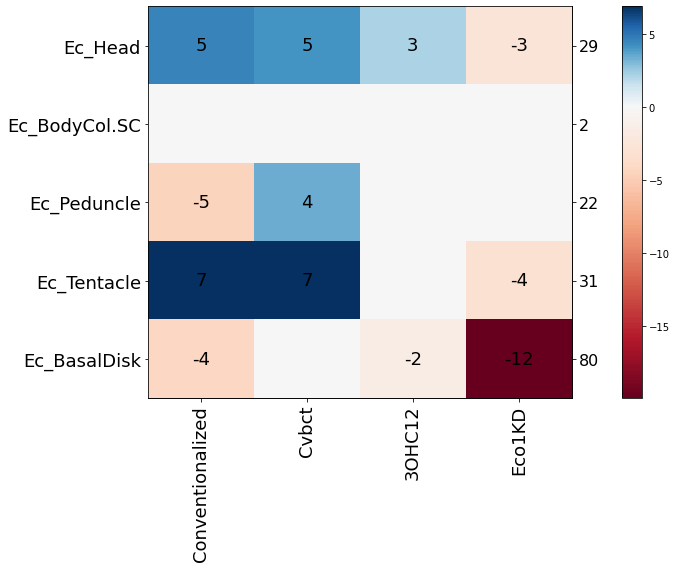

In [20]:
plot_heatmap_of_clusterings(ectoderm_statistic,ectoderm_pvalue,ectoderm_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "ectoderm_ttest.jpg",
                           size=(10,8),fonts=18, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


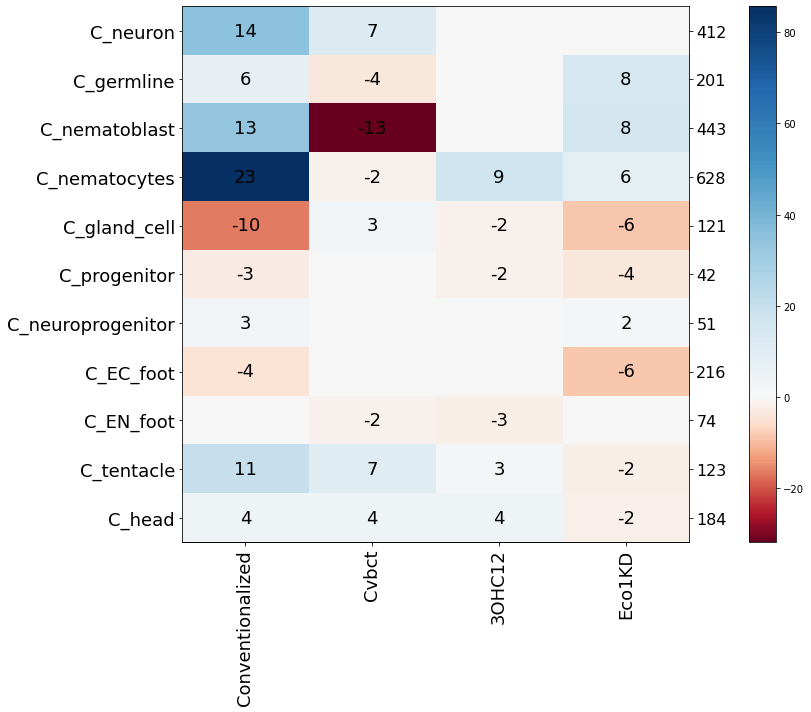

In [21]:
plot_heatmap_of_clusterings(supercluster_statistic,supercluster_pvalue,supercluster_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "supercluster_ttest.jpg",
                           size=(12,10),fonts=18, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


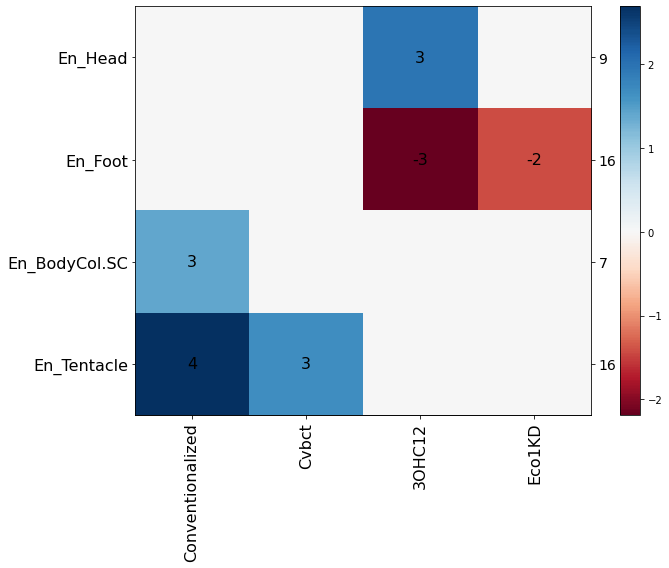

In [22]:
plot_heatmap_of_clusterings(endoderm_statistic,endoderm_pvalue,endoderm_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "endoderm_ttest.jpg",
                           size=(10,8),fonts=16)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


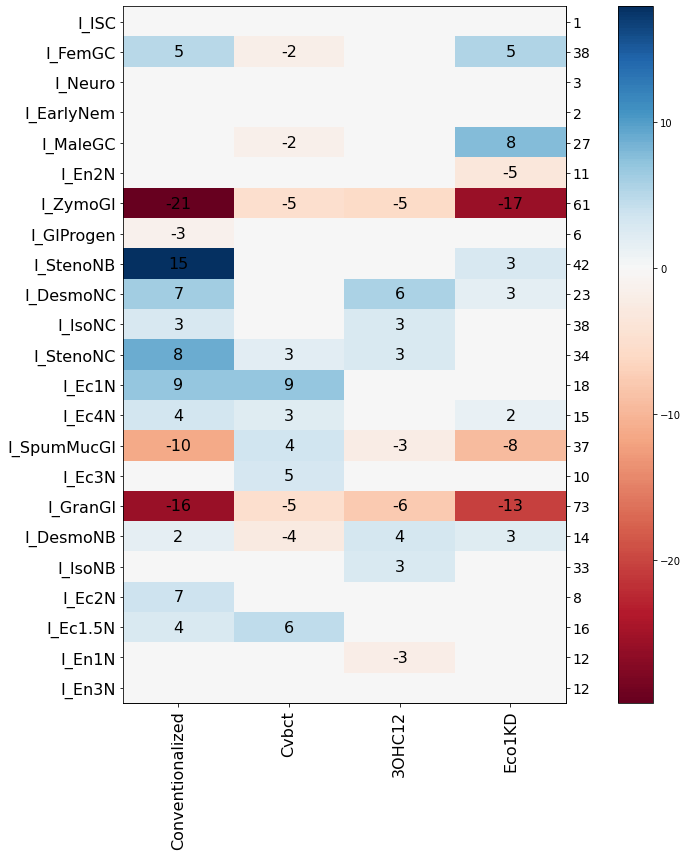

In [23]:
plot_heatmap_of_clusterings(interstitial_statistic,interstitial_pvalue,interstitial_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "interstitial_ttest.jpg",
                           size=(10,12),fonts=16, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


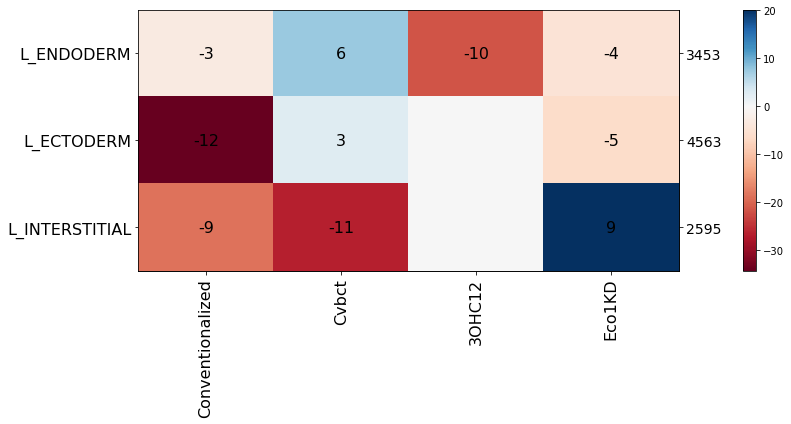

In [24]:
plot_heatmap_of_clusterings(l_supercluster_statistic,l_supercluster_pvalue,l_supercluster_query,sliced_targets,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "l_supercluster_ttest.jpg",
                           size=(12,6),fonts=16, padx=0.09)

[*] Adjusting statistic values to pvalue ...
[*] Setting values with pval > 0.05 to 0 ...
[*] DONE pvalue adjustment
[*] Start plotting ...


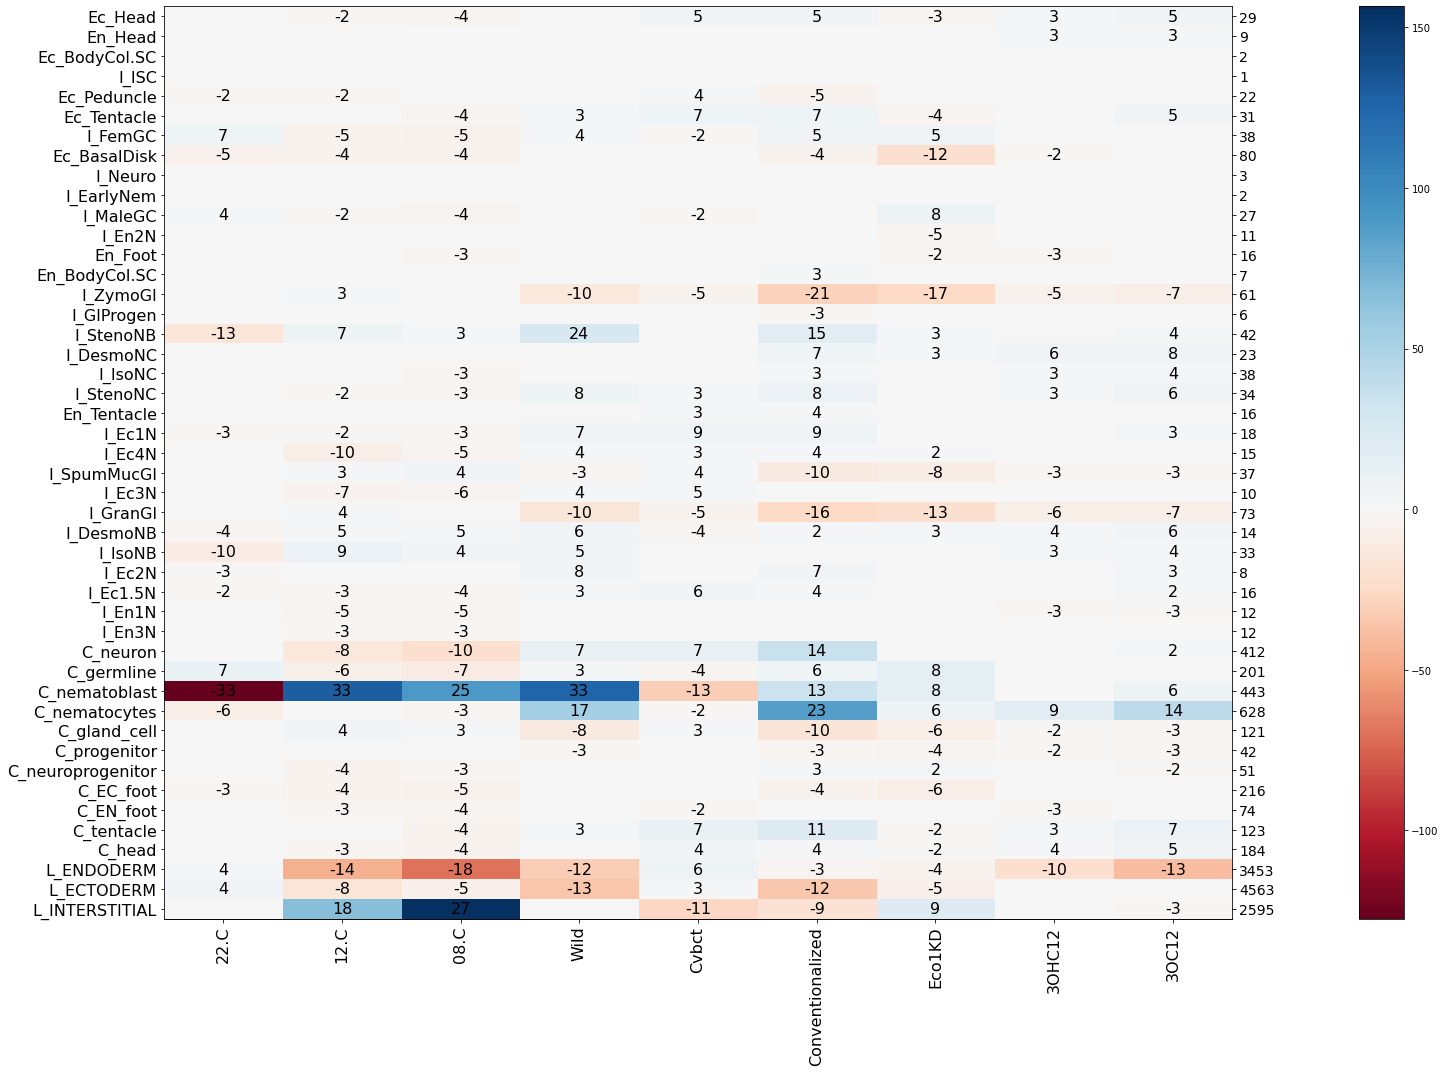

In [25]:
plot_heatmap_of_clusterings(statistic,pvalue,query_number,target_number,
                            "Cell-Type specific gene expression between RNA-Seq experiments",
                           "Hydra vulgaris cell types", "Hydra vulgaris RNA-Seq experiments",
                            result_figure_path + "test.jpg",
                           size=(22,15),fonts=16, padx=0.09)